## Data insights

Psychology's interpretation of human behavior depends on who writes it. This notebook maps where psychology research is produced, how concentrated that production is, and how the distribution has shifted since 2003.

Findings, covering 2011-2022 unless noted:
1. Psychology's share of national output is higher in the WEIRD world. Among the top 15 science producers, every WEIRD country devotes at least 2.2% of its output to psychology and every non-WEIRD country devotes 1.3% or less.
2. The US leads the world in psychology. It writes 33.8% of it, against 17.4% of all science and 4.3% of world population.
3. China leads the world in science and ranks fifth in psychology, which is 0.5% of its science output.
4. The US share of psychology has nearly halved since 2003, from 46.8% to 27.7%, while China's rose from 0.7% to 11.1%.

This notebook loads `data/processed/publication_data.csv`, produced by `00_data_processing.ipynb`. It writes the PNGs in `figures/` and the Plotly specs behind `docs/index.html`.


### Setup


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import plotly.graph_objects as go
import statsmodels.api as sm
from cmcrameri import cm


### Figure guidelines

Shared palette, Plotly template, and helpers. Site figures are built bare and take their titles from `index.html`; `titled()` puts titles back on for the PNGs in `figures/`.


In [ ]:
SERIF, SANS, BG = "Libre Baskerville", "Libre Franklin", "white"
MAP_CMAP = cm.turku_r

UK_C, CA_C, DE_C = [to_hex(MAP_CMAP(p)) for p in (0.56, 0.20, 0.85)]
FAINT = to_hex(MAP_CMAP(0.12))  # unlabelled scatter markers
INK = to_hex(MAP_CMAP(0.62))    # secondary scatter labels
LEAD, ALT = "#02397a", "#D55E00"
print(f"style.css swatches: {LEAD} / {ALT} | support {UK_C} {CA_C} {DE_C} {FAINT} {INK}")
GRID = "#F0F0F0"  # chart gridlines
PAD = 48          # left inset for PNG title blocks, matching the site's text column

HOVER = dict(bgcolor="white", 
             bordercolor="rgba(0, 0, 0, 0.1)",
             font=dict(family=SANS, size=12, color="black"))

AXIS_DEFAULTS = dict(gridcolor="white", linecolor="white", ticks="", zerolinecolor="white",
                     zerolinewidth=2, automargin=True, title=dict(standoff=15))

SITE_TEMPLATE = dict(layout=dict(
    autotypenumbers="strict", hovermode="closest", font=dict(color="#2a3f5f"),
    hoverlabel=dict(align="left"), paper_bgcolor="white", plot_bgcolor="#E5ECF6",
    geo=dict(subunitcolor="white", showland=True, showlakes=True, lakecolor="white"),
    xaxis=AXIS_DEFAULTS, yaxis=AXIS_DEFAULTS,
))

def titled(fig, title, subtitle, legend=None, png=None, height=600, margin=None, title_top=26):
    """
    Add title/subtitle/legend back onto bare site figures, for display and figures/PNGs.
    The block sits flush left above the plot, the way index.html lays it out.

    """
    width = 800
    out = go.Figure(fig).update_layout(
        width=width, height=height, autosize=False, margin=margin,
        title=dict(
            x=PAD / width, xref="container", xanchor="left", y=1 - title_top / height, yanchor="top",
            font=dict(family=SERIF, size=18, color="black"),
            text=f"{title}<br><span style='font-family:{SANS};font-size:13px'>{subtitle}</span>",
        ),
    )
    if legend:
        # annotations take paper coordinates only, so convert from pixels;
        # 48px under the title puts the legend below the subtitle, as index.html has it
        left, right = out.layout.margin.l, out.layout.margin.r
        plot_height = height - out.layout.margin.t - out.layout.margin.b
        out.add_annotation(
            x=(PAD - left) / (width - left - right),
            y=(height - out.layout.margin.b - title_top - 48) / plot_height,
            xref="paper", yref="paper", xanchor="left", showarrow=False,
            font=dict(family=SANS, size=12, color="black"),
            text="&nbsp;&nbsp;&nbsp;&nbsp;".join(
                f"<span style='color:{color}'>●</span> {label}" for label, color in legend),
        )
    if png:
        out.write_image(f"../figures/{png}")
    return out

def write_chart_data(charts, path="../docs/js/chart-data.js"):
    """
    Produces script with plotly specs (../docs/js/chart-data.js).

    """
    blocks = []
    for chart_id, fig in charts.items():
        spec = json.loads(fig.to_json())
        spec["layout"]["template"] = SITE_TEMPLATE
        traces = ",\n  ".join(json.dumps(trace) for trace in spec["data"])
        blocks.append(f'{{"id": "{chart_id}",\n "data": [\n  {traces}\n ],\n'
                      f' "layout": {json.dumps(spec["layout"], indent=2)}}}')
    Path(path).write_text(
        "/* Generated by notebooks/01_data_insights.ipynb.\n"
        "   Plotly specs for the four figures in index.html. */\n"
        "window.CHART_SPECS = [\n" + ",\n".join(blocks) + "\n];\n")
    print(f"wrote {path} ({Path(path).stat().st_size:,} bytes)")

def short_number(number):
    """
    Returns str: the short-form (K or M) of a long-form number (ex. 1000 becomes 1K).
     
    """

    for cutoff, suffix in ((1_000_000, "M"), (1_000, "K")):
        if abs(number) >= cutoff:
            scaled = number / cutoff
            return f"{int(scaled)}{suffix}" if scaled == int(scaled) else f"{round(scaled, 1)}{suffix}"
    return str(number)

def darken(hex_color, factor=0.72):
    """
    Returns str: hex_color scaled toward black (ex. 0.72 keeps 72% of each channel).

    """
    channels = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    return "#%02x%02x%02x" % tuple(int(c * factor) for c in channels)

def gradient_color(value, scale, low, high):
    """
    Get hex color for value in gradient
    """
    position = min(max((value - low) / (high - low), 0), 1) if high > low else 0.5
    index = min(int(position * (len(scale) - 1)), len(scale) - 2)
    fraction = position * (len(scale) - 1) - index
    start, end = (tuple(int(c[i:i + 2], 16) for i in (1, 3, 5)) for c in scale[index:index + 2])
    return "#%02x%02x%02x" % tuple(int(a + (b - a) * fraction) for a, b in zip(start, end))

style.css swatches: #02397a / #D55E00 | support #7d7b51 #efb1a1 #2e2e28 #fbc5c0 #6c6b4a


## Coverage and window

Cross-sectional summaries use 2011-2022, the most recent twelve years. Publication counts run 2003-2022 and the time series uses the full range.


In [3]:
merged_data = pd.read_csv("../data/processed/publication_data.csv")

wdi_cols = [c for c in merged_data.columns if c not in
            ['iso_alpha', 'Year', 'Publications', 'Country', 'data_source_flag']]
years_with_wdi = merged_data.loc[merged_data[wdi_cols].notna().any(axis=1), 'Year']

print(f"Country-year rows: {len(merged_data)}")
print(f"Distinct countries: {merged_data['Country'].nunique()}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Years with WDI coverage: {years_with_wdi.min()}-{years_with_wdi.max()} ({years_with_wdi.nunique()} years)")

Country-year rows: 4020
Distinct countries: 201
Years: 2003-2022
Years with WDI coverage: 2003-2022 (20 years)


In [4]:
mean_cols = [
    'GDP_per_capita', 'GDP_per_capita_PPP', 'GNI_per_capita_PPP', 'Population',
    'Tertiary_enrollment_pct', 'RnD_expenditure_pct', 'Researchers_per_million',
    'Education_expenditure_pct', 'Tertiary_education_expenditure_pct',
    'Urban_population_pct', 'Sci_tech_articles', 'Internet_users_pct',
]

country_summary = merged_data.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary['psych_share'] = country_summary['Publications'] / country_summary['SE_articles_total']
country_summary['log_publications'] = np.log1p(country_summary['Publications'])

print(f"Countries: {len(country_summary)}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Total psychology publications: {country_summary['Publications'].sum():,.0f}")
print(f"Years covered per country: {country_summary['n_years'].min()}-{country_summary['n_years'].max()} "
      f"(median {country_summary['n_years'].median():.0f})")
print(f"Zero publications: {(country_summary['Publications'] == 0).sum()}")
print(f"Missing publications entirely: {country_summary['Publications'].isna().sum()}")
print(f"Missing GDP_per_capita: {country_summary['GDP_per_capita'].isna().sum()}")

Countries: 201
Years: 2003-2022
Total psychology publications: 815,406
Years covered per country: 20-20 (median 20)
Zero publications: 10
Missing publications entirely: 0
Missing GDP_per_capita: 4


In [5]:
window = merged_data[merged_data['Year'].between(2011, 2022)]

country_summary_11_22 = window.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary_11_22['psych_share'] = (
    country_summary_11_22['Publications'] / country_summary_11_22['SE_articles_total'])
country_summary_11_22['log_publications'] = np.log1p(country_summary_11_22['Publications'])

print(f"Countries in 2011-2022 summary: {len(country_summary_11_22)}")
print(f"Total psychology publications (2011-2022): {country_summary_11_22['Publications'].sum():,.0f}")
print(f"Zero publications: {(country_summary_11_22['Publications'] == 0).sum()}")

Countries in 2011-2022 summary: 201
Total psychology publications (2011-2022): 596,911
Zero publications: 12


## Where psychology is written


### Distribution across countries


In [6]:
nonzero = country_summary_11_22['Publications'] > 0
q1, q2, q3 = country_summary_11_22.loc[nonzero, 'Publications'].quantile([0.25, 0.5, 0.75])
median = country_summary_11_22['Publications'].median()
plot_min = country_summary_11_22['Publications'].min()
plot_max = country_summary_11_22['Publications'].max()

print(f"zero contributions share: {(~nonzero).mean():.2%}")
print(f"min: {plot_min}, q1: {q1}, median (all): {median}, q2 (nonzero): {q2}, q3: {q3}, max: {plot_max}")

country_summary_11_22['quartile'] = 'Zero publications'
country_summary_11_22.loc[nonzero, 'quartile'] = pd.qcut(
    country_summary_11_22.loc[nonzero, 'Publications'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(f"\nCountries per quartile:\n{country_summary_11_22['quartile'].value_counts()}")

top_quartile = country_summary_11_22.sort_values('Publications', ascending=False)
bottom_quartile = country_summary_11_22[country_summary_11_22['Publications'] > 0].sort_values('Publications')

print(f"\nTop 5 contributors:\n{top_quartile.iloc[:5, :3]}")
print(f"\nBottom 5 contributors, non-zero:\n{bottom_quartile.iloc[:5, :3]}")


zero contributions share: 5.97%
min: 0.0, q1: 6.17, median (all): 34.99, q2 (nonzero): 45.41, q3: 700.51, max: 201664.58000000002

Countries per quartile:
quartile
Q1                   48
Q2                   47
Q3                   47
Q4                   47
Zero publications    12
Name: count, dtype: int64

Top 5 contributors:
    iso_alpha         Country  Publications
188       USA   United States     201664.58
62        GBR  United Kingdom      49574.46
45        DEU         Germany      38102.80
29        CAN          Canada      29663.27
32        CHN           China      27903.16

Bottom 5 contributors, non-zero:
    iso_alpha       Country  Publications
182       TUV        Tuvalu          0.05
112       MDV      Maldives          0.10
39        COM       Comoros          0.20
37        COK  Cook Islands          0.22
194       VUT       Vanuatu          0.40


### The US share


In [7]:
world_total_psych = country_summary_11_22['Publications'].sum()
us = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Publications'].values[0]
print(f"world total: {world_total_psych:,.0f}")
print(f"US share: {us / world_total_psych:.1%}")

world_pop = country_summary_11_22['Population'].sum()
us_pop = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Population'].values[0]
print(f"US share of population: {us_pop / world_pop:.1%}\n")

non_us = country_summary_11_22[country_summary_11_22['Country'] != 'United States'].sort_values('Publications', ascending=False)

for rank, (_, row) in enumerate(non_us[:4].iterrows(), start=2):
    ratio = us / row['Publications']
    pop_share = row['Population'] / world_pop
    pub_share = row['Publications'] / world_total_psych
    print(f"US is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of world publications "
          f"and {pop_share:.1%} of world population")

top_5_psych = us + top_quartile[1:5]['Publications'].sum()
print(f"\ntop 5 combined: {top_5_psych / world_total_psych:.1%} of world publications")

world total: 596,911
US share: 33.8%
US share of population: 4.3%

US is 4.1x United Kingdom (#2), who has 8.3% of world publications and 0.9% of world population
US is 5.3x Germany (#3), who has 6.4% of world publications and 1.1% of world population
US is 6.8x Canada (#4), who has 5.0% of world publications and 0.5% of world population
US is 7.2x China (#5), who has 4.7% of world publications and 18.4% of world population

top 5 combined: 58.1% of world publications


### All science and engineering subjects

Same aggregation over every S&E field, for comparison against the psychology counts above.


In [8]:
top_quartile_all_SE = country_summary_11_22.sort_values('SE_articles_total', ascending=False)

print(f"\nTop 5 contributors, all SE subjects:\n{top_quartile_all_SE[:5].loc[:, ['Country','SE_articles_total']]}")



Top 5 contributors, all SE subjects:
           Country  SE_articles_total
32           China         6192884.71
188  United States         5324328.63
79           India         1442145.44
45         Germany         1322304.22
88           Japan         1263777.51


In [9]:
world_total_all = country_summary_11_22['SE_articles_total'].sum()
cn = country_summary_11_22.loc[country_summary_11_22['Country'] == 'China', 'SE_articles_total'].values[0]
print(f"world total: {world_total_all:,.0f}")

non_cn = country_summary_11_22[country_summary_11_22['Country'] != 'China'].sort_values('SE_articles_total', ascending=False)

for rank, (_, row) in enumerate(non_cn[:4].iterrows(), start=2):
    ratio = cn / row['SE_articles_total']
    pop_share = row['Population'] / world_pop
    pub_share = row['SE_articles_total'] / world_total_all
    print(f"China is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of all world publications "
          f"and {pop_share:.1%} of world population")

top_5_total = cn + top_quartile_all_SE[1:5]['SE_articles_total'].sum()
print(f"\ntop 5 combined: {top_5_total / world_total_all:.1%} of all world publications")

world total: 30,603,567
China is 1.2x United States (#2), who has 17.4% of all world publications and 4.3% of world population
China is 4.3x India (#3), who has 4.7% of all world publications and 17.9% of world population
China is 4.7x Germany (#4), who has 4.3% of all world publications and 1.1% of world population
China is 4.9x Japan (#5), who has 4.1% of all world publications and 1.7% of world population

top 5 combined: 50.8% of all world publications


### Mapped


In [ ]:
map_scale = [to_hex(MAP_CMAP(i / 9)) for i in range(10)]
low, high = country_summary_11_22['log_publications'].min(), country_summary_11_22['log_publications'].max()

country_summary_11_22['hover_color'] = country_summary_11_22['log_publications'].map(
    lambda x: gradient_color(x, map_scale, low, high))
country_summary_11_22['pub_share_world'] = (country_summary_11_22['Publications'] / world_total_psych).round(6)
country_summary_11_22['pop_share_world'] = (country_summary_11_22['Population'] / world_pop).round(6)

pub_ticks = [0, 20, 200, 2000, 20000, 200000]

map_fig = go.Figure(go.Choropleth(
    locations=country_summary_11_22['iso_alpha'].tolist(),
    locationmode='ISO-3',
    z=country_summary_11_22['log_publications'].round(4).tolist(),
    colorscale=map_scale,
    customdata=country_summary_11_22[['Country', 'Publications', 'hover_color',
                                'pub_share_world', 'pop_share_world']].values.tolist(),
    hovertemplate="<b>%{customdata[0]} </b>"
                  "<span style='color:%{customdata[2]};vertical-align:middle'>■</span><br>"
                  "%{customdata[1]:,} publications<br>"
                  "%{customdata[3]:.1%} of world publications<br>"
                  "%{customdata[4]:.1%} of world population<extra></extra>",
    colorbar=dict(
        orientation='h', x=0.5, y=-0.12, xanchor='center', yanchor='middle',
        len=0.4, thickness=15, outlinewidth=0, ticks="",
        tickvals=[round(float(np.log1p(v)), 4) for v in pub_ticks],
        ticktext=[short_number(v) for v in pub_ticks],
        tickfont=dict(family=SANS, size=9, color="black"),
        title=dict(text="<b>Publications (Log Scale)</b>", side="top",
                   font=dict(family=SANS, size=12, color="black")),
    ),
))

map_fig.update_geos(showcountries=True, countrycolor="lightgray", countrywidth=0.5,
                    landcolor=BG, showframe=False, bgcolor=BG, fitbounds="locations")

map_fig.update_layout(
    # l=0 so the map starts flush with the text column
    # colorbar is placed in paper coords at x=0.5 to stay centered
    autosize=True, paper_bgcolor=BG, margin=dict(t=0, b=80, l=0, r=10, autoexpand=False),
    hoverlabel=HOVER,
)

titled(map_fig,
       "The US produced a third of the world's psychology publications",
       "Scopus Psychology Publications by Country (2011-2022), Fractional Contributions",
       png="main_map.png", height=574, margin=dict(t=122, b=86, l=PAD, r=20), title_top=37)


## Change over time


In [11]:
panel_cy = merged_data.groupby(['iso_alpha', 'Country', 'Year'], as_index=False)['Publications'].sum()

world_by_year = panel_cy.groupby('Year')['Publications'].sum()
panel_cy = panel_cy.merge(world_by_year.rename('world_total'), left_on='Year', right_index=True)
panel_cy['share_of_world'] = panel_cy['Publications'] / panel_cy['world_total']

trend_countries = {"USA":"United States", "GBR":"United Kingdom", "CAN":"Canada", "DEU":"Germany", "CHN":"China"}
trend_colors = {"United States": LEAD, 
                "China": ALT, 
                "United Kingdom": UK_C,
                "Canada": CA_C, 
                "Germany": DE_C}
legend_order = ["United States", "China", "United Kingdom", "Canada", "Germany"]

trend_fig = go.Figure()

for iso, name in trend_countries.items():
    sub = panel_cy[panel_cy['iso_alpha'] == iso].sort_values('Year')
    trend_fig.add_trace(go.Scatter(
        x=sub['Year'].tolist(), y=(sub['share_of_world'] * 100).round(4).tolist(),
        mode="lines+markers", name=name, showlegend=False,
        line=dict(color=trend_colors[name], width=3),
        marker=dict(size=6, color=trend_colors[name]),
        hovertemplate=f"<b>{name}</b><br>Year: %{{x}}<br>Share: %{{y:.2f}}%<extra></extra>",
    ))

trend_fig.update_xaxes(title="<b>Year</b>", showgrid=False, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))
trend_fig.update_yaxes(title="<b>Share of world psychology publications (%)</b>", showgrid=True,
                       gridcolor=GRID, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))

trend_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=20, b=70, l=52, r=20),
)

titled(trend_fig,
       "US psychology share fell as China overtook the UK, Canada, and Germany",
       "Annual share of world psychology publications (2003-2022), five largest producers",
       legend=[(name, trend_colors[name]) for name in legend_order],
       png="global_share_overtime.png", height=618, margin=dict(t=128, b=70, l=95, r=40), title_top=44)


In [12]:
# WEIRD country list from https://pmc.ncbi.nlm.nih.gov/articles/PMC12852971/
WEIRD = {"United Kingdom", 
         "United States", "Canada", 
         "Italy", 
         "Greece", "Germany", "Denmark", "Australia", 
         "Spain", "Netherlands", "Ireland", "France", 
         "Switzerland", "Belgium", "Sweden", "Norway", 
         "New Zealand", "Finland", "Austria", "Portugal"}

matched = panel_cy[panel_cy['Country'].isin(WEIRD)]['Country'].unique()
missing = WEIRD - set(matched)
assert not missing, f"WEIRD countries not found in Country column: {missing}"

def weird_share(year):
    share = panel_cy.loc[(panel_cy['Country'].isin(WEIRD)) & (panel_cy['Year'] == year),
                        'share_of_world'].sum()

    return float(share) * 100

print(f"Matched all {len(WEIRD)} WEIRD countries")
print(f"WEIRD share was {weird_share(2003):.1f}% in 2003 and {weird_share(2022):.1f}% in 2022")

Matched all 20 WEIRD countries
WEIRD share was 90.6% in 2003 and 67.5% in 2022


## Psychology's share of national output

Volume and share answer different questions. Volume is how much of the field a country writes; share is how much of that country's research system does the writing.


In [13]:
rho = country_summary_11_22[['Publications', 'SE_articles_total']].corr(method='spearman').loc['Publications', 'SE_articles_total']
print(f"Spearman rho = {rho:.3f}")

Spearman rho = 0.957


### Ranked by share

Ranking the 15 largest science producers by psychology's share of national output separates them cleanly on WEIRD status.


In [14]:
top_by_share = (country_summary_11_22
                .dropna(subset=['SE_articles_total', 'psych_share'])
                .nlargest(15, 'SE_articles_total')
                .sort_values('psych_share')
                .copy())

WEIRD_COLOR, NONWEIRD_COLOR = LEAD, ALT  # the shared pair from Figure guidelines

color_for = {c: (WEIRD_COLOR if c in WEIRD else NONWEIRD_COLOR) for c in top_by_share['Country']}
colors = [color_for[c] for c in top_by_share['Country']]

rank_fig = go.Figure()

rank_fig.add_trace(go.Bar(
    x=(top_by_share['psych_share'] * 100).round(3).tolist(),
    y=top_by_share['Country'].tolist(),
    orientation='h',
    marker=dict(color=colors),
    showlegend=False,
    hoverinfo="skip",
))

for country, share in zip(top_by_share['Country'], top_by_share['psych_share']):
    rank_fig.add_annotation(
        x=share * 100, y=country, xanchor="left", xshift=6, showarrow=False,
        text=f"<b>{share:.2%}</b>".replace('0%', '%').replace('.0%', '%'),
        font=dict(family=SANS, size=11, color=darken(color_for[country])))

rank_fig.update_xaxes(
    showgrid=False, showticklabels=False, zeroline=False,
    range=[0, top_by_share['psych_share'].max() * 100 * 1.005],
    domain=[0, 1]
    )

rank_fig.update_yaxes(
    showgrid=False, zeroline=False, showspikes=False, ticklabelstandoff=16,
    automargin=False, tickfont=dict(family=SANS, size=12))

rank_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG, bargap=0.42,
    font=dict(family=SANS, size=12, color="black"),
    # l measured for longest label "United Kingdom"; b is small because the
    # x-axis is hidden, so no tick labels or axis title need room below
    hoverlabel=HOVER, margin=dict(t=20, b=20, l=109, r=51))

titled(rank_fig,
       "WEIRD countries hold the top eight positions in psychology's share",
       "Top 15 countries by total science output (2011-2022), ranked by psychology's share of national science output",
       legend=[("WEIRD", WEIRD_COLOR), ("Non-WEIRD", NONWEIRD_COLOR)],
       png="psych_share_ranked.png", height=643, margin=dict(t=134, b=24, l=158, r=90), title_top=45)


### Volume against share


In [15]:
top = (country_summary_11_22
       .dropna(subset=['SE_articles_total', 'psych_share'])
       .nlargest(15, 'SE_articles_total')
       .copy())

HILITE = {'United States': LEAD, 
          'China': ALT}

over_china = ['Germany', 'United Kingdom', 'Canada']
for item in over_china:
    HILITE[item] = INK

scatter_fig = go.Figure()

scatter_fig.add_trace(go.Scatter(
    x=top['SE_articles_total'].tolist(),
    y=top['Publications'].tolist(),
    mode="markers", showlegend=False,
    marker=dict(size=11, line=dict(width=0.8, color="white"),
                color=[HILITE.get(c, FAINT) for c in top['Country']]),
    customdata=top[['Country', 'psych_share']].values.tolist(),
    hovertemplate=("<b>%{customdata[0]}</b><br>"
                   "%{x:,.0f} science publications<br>"
                   "%{y:,.0f} psychology publications<br><extra></extra>")))

LABELLED = {'United States', 'China', 'Germany', 'United Kingdom', 'Canada'}

for _, r in top[top['Country'].isin(LABELLED)].iterrows():
    scatter_fig.add_annotation(
        x=np.log10(r['SE_articles_total']), y=np.log10(r['Publications']),
        text=r['Country'], showarrow=False, xanchor="left", xshift=13,
        font=dict(family=SANS, size=11, color=HILITE.get(r['Country'], INK)))

scatter_fig.update_xaxes(
    type="log", title="<b>Science publications, all subjects</b>",
    showgrid=True, gridcolor=GRID, zeroline=False,
    tickvals=[5e5, 1e6, 2e6, 4e6, 6e6],
    ticktext=[short_number(v) for v in [5e5, 1e6, 2e6, 4e6, 6e6]],
    tickfont=dict(family=SANS, size=12))

scatter_fig.update_yaxes(
    type="log", title="<b>Psychology publications</b>",
    showgrid=True, gridcolor=GRID, zeroline=False,
    tickvals=[2e3, 5e3, 1e4, 5e4, 2e5],
    ticktext=[short_number(v) for v in [2e3, 5e3, 1e4, 5e4, 2e5]],
    tickfont=dict(family=SANS, size=12))

scatter_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    # l as in trend_fig, but wider tick labels ("200K") need more room
    hoverlabel=HOVER, margin=dict(t=30, b=55, l=70, r=40))

titled(scatter_fig,
       "China leads in science and ranks fifth in psychology",
       "Top 15 countries by total science output (2011-2022)",
       png="science_vs_psych_scatter.png", height=721, margin=dict(t=121, b=75, l=113, r=60), title_top=47)


## Predictors of psychology's share

Does national income explain how much of a research system goes to psychology? Below: distribution checks, then a Poisson model that keeps the zero-publication countries in.


### Distribution checks


In [16]:
base = country_summary.dropna(subset=['SE_articles_total']).copy()
print("Country totals, 2003-2022\n")
print(base[['Publications', 'SE_articles_total', 'psych_share']].describe().round(4).to_string())

Country totals, 2003-2022

       Publications  SE_articles_total  psych_share
count      201.0000       2.010000e+02     201.0000
mean      4056.7460       2.162312e+05       0.0141
std      22347.5618       8.697918e+05       0.0202
min          0.0000       4.660000e+00       0.0000
25%          6.1900       6.330000e+02       0.0048
50%         39.8400       5.341240e+03       0.0101
75%        594.9700       8.165708e+04       0.0179
max     296045.2000       8.419082e+06       0.2260


In [17]:
# Funnel diagnostic: psych_share is a ratio, so countries with small
# denominators vary more by construction than by behavior

base['granularity'] = 1 / base['SE_articles_total']
base['den_decile'] = pd.qcut(base['SE_articles_total'], 10, labels=False)

spread = base.groupby('den_decile').agg(
    n=('psych_share', 'size'),
    den_max=('SE_articles_total', 'max'),
    granularity=('granularity', 'median'),
    share_sd=('psych_share', 'std'),
    share_iqr=('psych_share', lambda x: x.quantile(.75) - x.quantile(.25)),
).round(5)

spread['granularity_ratio'] = spread['granularity'] / spread['share_sd']

print("Spread in psych_share by denominator decile\n")
print(spread.to_string())

Spread in psych_share by denominator decile

             n     den_max  granularity  share_sd  share_iqr  granularity_ratio
den_decile                                                                     
0           21      146.03      0.01760   0.05233    0.01078           0.336327
1           20      307.59      0.00451   0.02286    0.01586           0.197288
2           20     1109.49      0.00156   0.00779    0.00731           0.200257
3           20     2260.62      0.00059   0.00834    0.01076           0.070743
4           20     5341.24      0.00029   0.00683    0.00899           0.042460
5           20    13143.45      0.00010   0.00924    0.01624           0.010823
6           20    44374.84      0.00004   0.00776    0.00648           0.005155
7           20   160320.78      0.00001   0.01009    0.01404           0.000991
8           20   385289.99      0.00000   0.01161    0.01658           0.000000
9           20  8419082.31      0.00000   0.01298    0.01945           0.00

In [18]:
# smallest denominator decile where measurement granularity is small relative
# to the spread in psych_share; applied only to the correlation matrix below
THRESHOLD = 1500
country_summary_noise_cutoff = base[(base['SE_articles_total'] >= THRESHOLD) &
                                    (base['Publications'] > 0)]
print(f"n = {len(country_summary_noise_cutoff)}")

n = 132


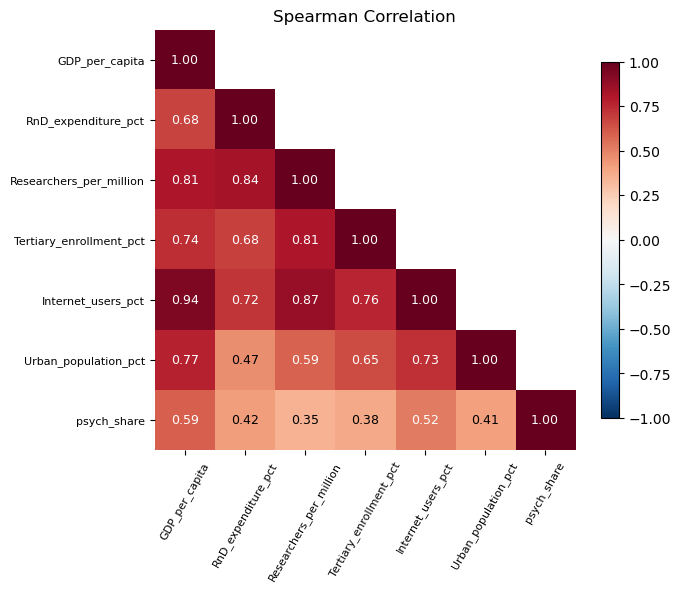

In [19]:
preds = ['GDP_per_capita', 
         'RnD_expenditure_pct',
         'Researchers_per_million', 
         'Tertiary_enrollment_pct',
         'Internet_users_pct', 
         'Urban_population_pct',
         'psych_share']

sub = country_summary_noise_cutoff[preds].dropna()
spear = sub.corr(method='spearman')
spear_masked = spear.where(np.tril(np.ones(spear.shape)).astype(bool))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spear_masked, cmap='RdBu_r', vmin=-1, vmax=1, origin='upper')

ax.set_xticks(range(len(spear)))
ax.set_xticklabels(spear.columns, rotation=60, fontsize=8)
ax.set_yticks(range(len(spear)))
ax.set_yticklabels(spear.columns, fontsize=8)
ax.set_title('Spearman Correlation')

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(spear)):
    for j in range(len(spear)):
        val = spear_masked.iloc[i, j]
        if pd.notna(val):
            val = float(val) # type: ignore
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

1,173 of 4,020 country-year observations are zero (29.2%), 100 of which have no GDP per capita data


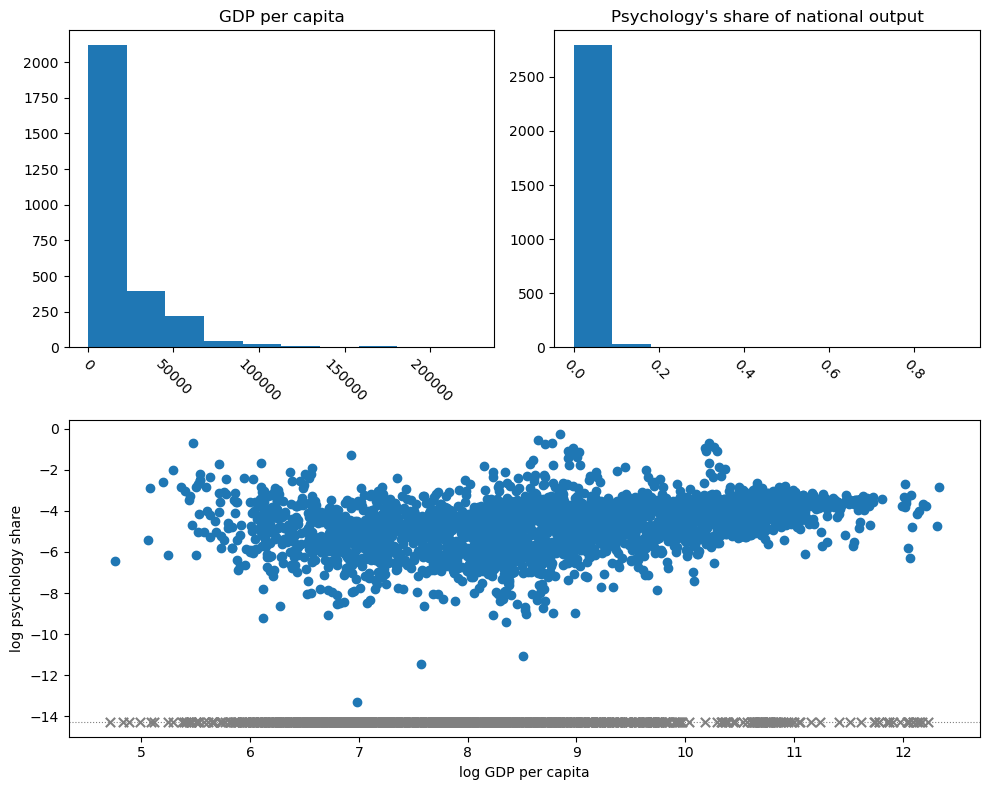

In [20]:
merged_data['psych_share'] = merged_data['Publications'] / merged_data['SE_articles_total']
merged_data_nonzero = merged_data[merged_data['Publications'] > 0]
merged_data_zeros = merged_data[merged_data['Publications'] == 0].dropna(subset=['GDP_per_capita'])

n_zero = (merged_data['Publications'] == 0).sum()
print(f"{n_zero:,} of {len(merged_data):,} country-year observations are zero "
      f"({n_zero / len(merged_data):.1%})"
      f", {len(merged_data[merged_data['Publications'] == 0]) - len(merged_data_zeros)} of which have no GDP per capita data")


fig = plt.figure(figsize=(10,8))

ax1 = plt.subplot2grid((2, 2), (0,0))
ax1.hist(merged_data_nonzero['GDP_per_capita'])
ax1.set_title('GDP per capita')

ax2 = plt.subplot2grid((2, 2), (0,1))
ax2.hist(merged_data_nonzero['psych_share'])
ax2.set_title("Psychology's share of national output")

ax3 = plt.subplot2grid((2, 2), (1,0), colspan=2)

x = np.asarray(np.log(merged_data_nonzero['GDP_per_capita']))
y = np.asarray(np.log(merged_data_nonzero['psych_share']))
ax3.scatter(x, y)
ax3.set_xlabel('log GDP per capita')
ax3.set_ylabel('log psychology share')
floor = y.min() - 1.0
ax3.scatter(np.log(merged_data_zeros['GDP_per_capita']), [floor] * len(merged_data_zeros),
            marker='x', s=45, color='gray')
ax3.axhline(floor, color='gray', lw=0.8, ls=':')
ax3.text(x.min(), floor + 0.25, f'{len(merged_data_zeros)} countries with zero psychology publications '
         '— undefined in logs', fontsize=8, color='gray')

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()

The dependent variable has a mass of zeros that logs cannot take, and the variance grows with the mean. Both rule out OLS on a logged share, so the models below use Poisson pseudo-maximum likelihood with total S&E output as an offset.


### Panel setup


In [21]:
# the denominator cutoff used for the correlations above is dropped here:
# PPML handles small denominators and zeros directly
panel = merged_data.dropna(subset=['GDP_per_capita', 'SE_articles_total']).copy()
panel = panel[panel['SE_articles_total'] > 0].copy()

panel['log_gdp'] = np.log(panel['GDP_per_capita'])
panel['offset'] = np.log(panel['SE_articles_total'])

print(f"Panel: {len(panel)} country-years, {panel['iso_alpha'].nunique()} countries, "
      f"{panel['Year'].min()}-{panel['Year'].max()}")
print(f"Zero-publication country-years retained: {(panel['Publications'] == 0).sum()} "
      f"({(panel['Publications'] == 0).mean():.1%}) ")

balance = panel.groupby('Year').size()
print(f"Country-years per year: min {balance.min()} ({balance.idxmin()}), "
      f"max {balance.max()} ({balance.idxmax()})")

zero_by_country = panel.groupby('iso_alpha')['Publications'].apply(lambda x: (x == 0).mean())
print("\nHighest share of zero-publication years, by country:")
print(zero_by_country.sort_values(ascending=False).head(20))

Panel: 3879 country-years, 197 countries, 2003-2022
Zero-publication country-years retained: 1046 (27.0%) 
Country-years per year: min 191 (2005), max 196 (2009)

Highest share of zero-publication years, by country:
iso_alpha
GNQ    1.000000
PLW    1.000000
STP    1.000000
FSM    1.000000
DJI    1.000000
TLS    1.000000
KIR    1.000000
NRU    1.000000
MHL    1.000000
VUT    0.950000
LCA    0.950000
MDV    0.950000
SLB    0.950000
TKM    0.950000
COM    0.950000
TUV    0.941176
ATG    0.900000
WSM    0.900000
AND    0.900000
ERI    0.888889
Name: Publications, dtype: float64


### Offset check

Total S&E output enters as an offset, which forces its coefficient to 1.

In [22]:
year_dummies = pd.get_dummies(panel['Year'], prefix='yr', drop_first=True, dtype=float)

Xp_unrestricted = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'offset']].rename(columns={'offset': 'log_total'}), year_dummies], axis=1
))
ppml_unrestricted = sm.GLM(panel['Publications'], Xp_unrestricted, family=sm.families.Poisson()).fit(
    cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

b = ppml_unrestricted.params['log_total']
se = ppml_unrestricted.bse['log_total']
print(f"unrestricted log_total coef: {b:.3f} (se {se:.3f})")
print(f"test coef == 1: z = {(b - 1) / se:.2f}")

unrestricted log_total coef: 0.997 (se 0.047)
test coef == 1: z = -0.06


### Model 1: income, year fixed effects

Year effects absorb anything moving the whole world at once, such as Scopus widening its coverage.


In [23]:
# without year fixed effects
X_plain = sm.add_constant(panel[['log_gdp']])
ppml_plain = sm.GLM(
    panel['Publications'], X_plain, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

# with year fixed effects
X_year = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_year = sm.GLM(
    panel['Publications'], X_year, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, no year FE  : {ppml_plain.params['log_gdp']:.3f} (se {ppml_plain.bse['log_gdp']:.3f})")
print(f"log_gdp, with year FE: {ppml_year.params['log_gdp']:.3f} (se {ppml_year.bse['log_gdp']:.3f})")

log_gdp, no year FE  : 0.826 (se 0.106)
log_gdp, with year FE: 0.826 (se 0.109)


### Model 2: adding country fixed effects

Country effects strip out the between-country ranking, leaving only variation within a country over time.


In [24]:
country_dummies = pd.get_dummies(panel['iso_alpha'], prefix='c', drop_first=True, dtype=float)

X_country = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies, country_dummies], axis=1))
ppml_country = sm.GLM(
    panel['Publications'], X_country, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, year FE only   : {ppml_year.params['log_gdp']:.3f} (se {ppml_year.bse['log_gdp']:.3f})")
print(f"log_gdp, with country FE: {ppml_country.params['log_gdp']:.3f} (se {ppml_country.bse['log_gdp']:.3f})")

log_gdp, year FE only   : 0.826 (se 0.109)
log_gdp, with country FE: 0.252 (se 0.251)


Country fixed effects drop the income coefficient from 0.83 to 0.25, with a standard error about as large. The gradient is almost entirely between countries: richer countries devote more of their research systems to psychology, but a country growing richer does not measurably shift its own. Dispersion far exceeds the Poisson assumption in both specifications, which is why every model is fit with standard errors clustered by country.


### Model 3: income x year trend

Interacting income with a year trend asks whether the gradient itself is changing.


In [25]:
panel['log_gdp_x_trend'] = panel['log_gdp'] * (panel['Year'] - 2011)
base_cols = panel[['log_gdp', 'log_gdp_x_trend']]

specs = {
    'year FE only (between-country)': [base_cols, year_dummies],
    'adding country FE (within-country)': [base_cols, year_dummies, country_dummies],
}

trend_fits = {}
for label, parts in specs.items():
    f = sm.GLM(panel['Publications'], sm.add_constant(pd.concat(parts, axis=1)),
               family=sm.families.Poisson(), offset=panel['offset']
              ).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})
    trend_fits[label] = f
    print(f"\n{label}")
    print(f"  log_gdp (at 2011): {f.params['log_gdp']:.3f} (se {f.bse['log_gdp']:.3f})")
    print(f"  log_gdp x year trend: {f.params['log_gdp_x_trend']:.3f} "
          f"(se {f.bse['log_gdp_x_trend']:.3f}), z = "
          f"{f.params['log_gdp_x_trend'] / f.bse['log_gdp_x_trend']:.2f}")

ppml_trend = trend_fits['year FE only (between-country)']
b_main, b_trend = ppml_trend.params['log_gdp'], ppml_trend.params['log_gdp_x_trend']

print("\nImplied income gradient (year FE only):")
for year in [2003, 2009, 2011, 2016, 2022]:
    effect = b_main + b_trend * (year - 2011)
    print(f"  {year}: {effect:.3f}  ({(2**effect - 1) * 100:.0f}% more psych output per GDP doubling)")


year FE only (between-country)
  log_gdp (at 2011): 0.904 (se 0.107)
  log_gdp x year trend: -0.016 (se 0.007), z = -2.18



adding country FE (within-country)
  log_gdp (at 2011): 0.176 (se 0.134)
  log_gdp x year trend: -0.024 (se 0.005), z = -4.53

Implied income gradient (year FE only):
  2003: 1.030  (104% more psych output per GDP doubling)
  2009: 0.935  (91% more psych output per GDP doubling)
  2011: 0.904  (87% more psych output per GDP doubling)
  2016: 0.825  (77% more psych output per GDP doubling)
  2022: 0.731  (66% more psych output per GDP doubling)


The income gradient flattens over time: a GDP doubling bought more psychology output in 2003 than in 2022, consistent with the widening contributor base in the time series above.


### Model comparison


In [26]:
models = {
    "1  income + year FE": ppml_year,
    "2  + country FE": ppml_country,
    "3  income x year trend": ppml_trend,
}

print(f"{'model':24s} {'log_gdp':>8s} {'se':>7s} {'chi2/df':>8s} {'converged':>10s}")
for label, fit in models.items():
    print(f"{label:24s} {fit.params['log_gdp']:8.3f} {fit.bse['log_gdp']:7.3f} "
          f"{fit.pearson_chi2 / fit.df_resid:8.2f} {str(fit.converged):>10s}")

model                     log_gdp      se  chi2/df  converged
1  income + year FE         0.826   0.109    47.79       True
2  + country FE             0.252   0.251     6.30       True
3  income x year trend      0.904   0.107    51.21       True


## Export

Generate `docs/js/chart-data.js` for `docs/index.html`.


In [27]:
write_chart_data({"c1": map_fig, "c2": rank_fig, "c3": trend_fig, "c4": scatter_fig})

wrote ../docs/js/chart-data.js (32,985 bytes)
